# 13 · Dimensionality Reduction — PCA & t-SNE

**Difficulty:** Intermediate | **Time:** ~2.5 hours

## Table of Contents
1. The Curse of Dimensionality
2. Principal Component Analysis (PCA)
3. How Many Components?
4. PCA for Visualization
5. t-SNE for High-Dimensional Visualization
6. PCA as Feature Engineering for ML
7. Real-World: Image Compression with PCA

## 1. The Curse of Dimensionality

As dimensions increase:
- Data becomes sparse
- Distance measures break down
- Models overfit more easily
- Training gets exponentially slower

**Solution:** Reduce dimensions while keeping most information.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits, load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')
print("Ready ✓")

Ready ✓


## 2. PCA — Principal Component Analysis

**Idea:** Find the directions (principal components) in the data that capture the most variance.

- PC1 captures the most variance
- PC2 captures the second most, **orthogonal** to PC1
- Each component is a linear combination of original features

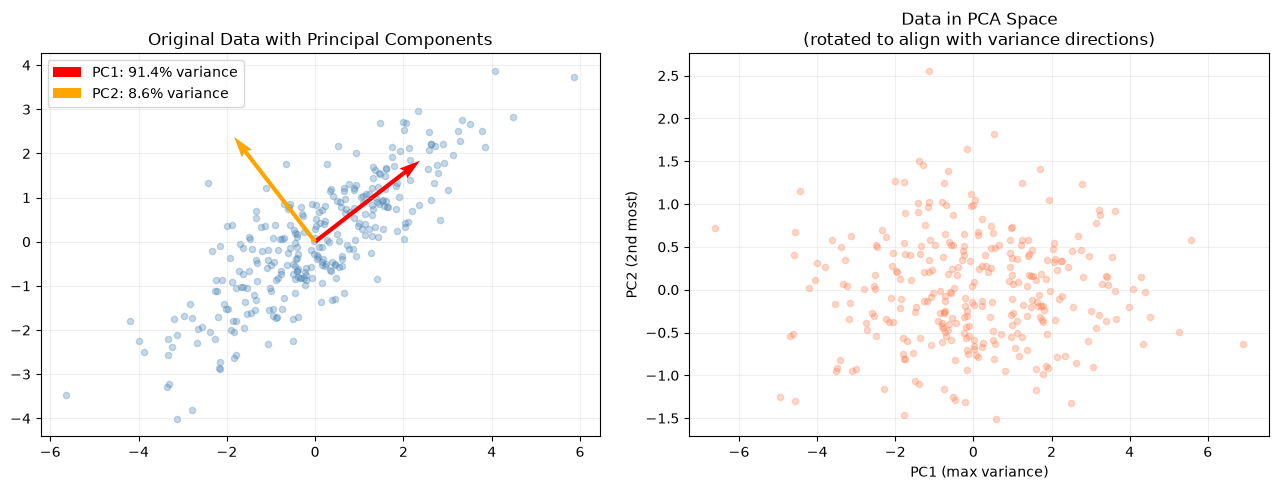

PC1 direction: [0.791 0.612]
PC2 direction: [-0.612  0.791]
Variance explained: [0.914 0.086]


In [2]:
# Demonstrate PCA visually with 2D data
np.random.seed(42)
mean = [0, 0]
cov = [[3, 2], [2, 2]]
X_2d = np.random.multivariate_normal(mean, cov, 300)

pca_2d = PCA(n_components=2)
pca_2d.fit(X_2d)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Original data with PCA directions
axes[0].scatter(X_2d[:,0], X_2d[:,1], alpha=0.3, s=20, color='steelblue')
# Draw principal components
scale = 3
for i, (ev, label) in enumerate(zip(pca_2d.components_, ['PC1','PC2'])):
    color = 'red' if i == 0 else 'orange'
    var_exp = pca_2d.explained_variance_ratio_[i]
    axes[0].quiver(0, 0, ev[0]*scale, ev[1]*scale, color=color, 
                    scale=1, scale_units='xy', angles='xy',
                    label=f'{label}: {var_exp:.1%} variance')
axes[0].set_aspect('equal')
axes[0].set_title("Original Data with Principal Components")
axes[0].legend()
axes[0].grid(alpha=0.2)

# Projected data
X_pca = pca_2d.transform(X_2d)
axes[1].scatter(X_pca[:,0], X_pca[:,1], alpha=0.3, s=20, color='coral')
axes[1].set_xlabel("PC1 (max variance)"); axes[1].set_ylabel("PC2 (2nd most)")
axes[1].set_title("Data in PCA Space\n(rotated to align with variance directions)")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig("/tmp/pca_2d.png", dpi=100)
plt.show()

print(f"PC1 direction: {pca_2d.components_[0].round(3)}")
print(f"PC2 direction: {pca_2d.components_[1].round(3)}")
print(f"Variance explained: {pca_2d.explained_variance_ratio_.round(3)}")

## 3. How Many Components to Keep?

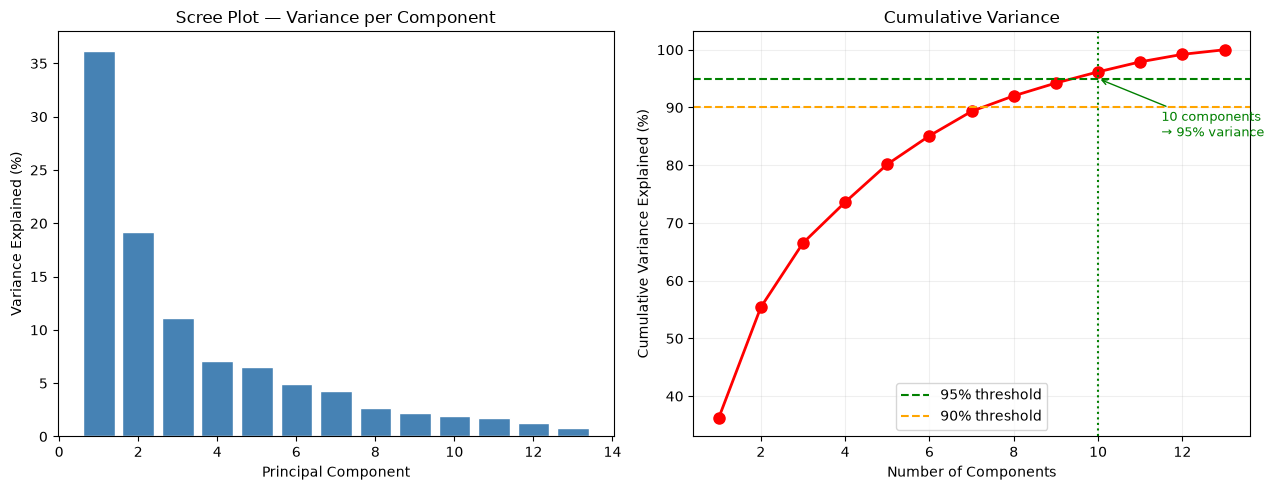

Components for 90% variance: 8
Components for 95% variance: 10


In [3]:
# Wine dataset — 13 features
wine = load_wine()
X_wine = StandardScaler().fit_transform(wine.data)

pca_full = PCA()
pca_full.fit(X_wine)

# Scree plot
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Individual variance
axes[0].bar(range(1, 14), pca_full.explained_variance_ratio_ * 100,
             color='steelblue', edgecolor='white')
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Explained (%)")
axes[0].set_title("Scree Plot — Variance per Component")

# Cumulative variance
axes[1].plot(range(1, 14), cumvar * 100, 'ro-', ms=8, linewidth=2)
axes[1].axhline(95, color='green', linestyle='--', linewidth=1.5, label='95% threshold')
axes[1].axhline(90, color='orange', linestyle='--', linewidth=1.5, label='90% threshold')
n_95 = np.argmax(cumvar >= 0.95) + 1
axes[1].axvline(n_95, color='green', linestyle=':', linewidth=1.5)
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance Explained (%)")
axes[1].set_title("Cumulative Variance")
axes[1].legend(); axes[1].grid(alpha=0.2)
axes[1].annotate(f'{n_95} components\n→ 95% variance', xy=(n_95, 95),
                  xytext=(n_95+1.5, 85), fontsize=9,
                  arrowprops=dict(arrowstyle='->', color='green'), color='green')

plt.tight_layout()
plt.savefig("/tmp/pca_scree.png", dpi=100)
plt.show()
print(f"Components for 90% variance: {np.argmax(cumvar >= 0.90) + 1}")
print(f"Components for 95% variance: {np.argmax(cumvar >= 0.95) + 1}")

## 4. PCA for 2D Visualization

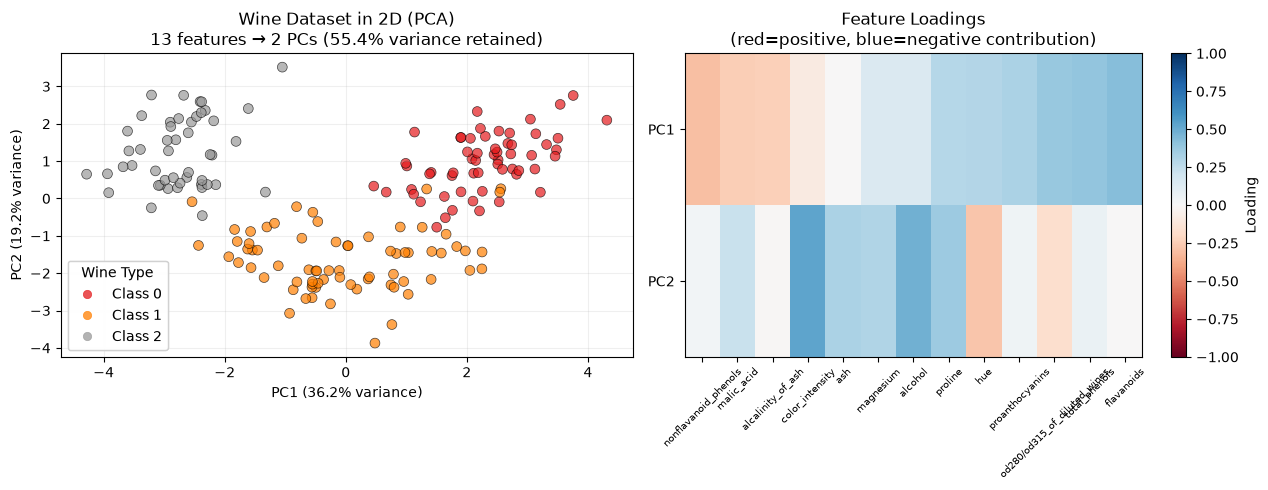

In [4]:
# Visualize 13-dimensional wine data in 2D
pca_2 = PCA(n_components=2)
X_wine_2d = pca_2.fit_transform(X_wine)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 2D scatter colored by wine type
scatter = axes[0].scatter(X_wine_2d[:,0], X_wine_2d[:,1], 
                            c=wine.target, cmap='Set1', s=50, alpha=0.7, edgecolors='k', lw=0.5)
handles, _ = scatter.legend_elements()
legend = axes[0].legend(handles, ['Class 0','Class 1','Class 2'], title="Wine Type")
axes[0].add_artist(legend)
axes[0].set_xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]:.1%} variance)")
axes[0].set_ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]:.1%} variance)")
axes[0].set_title(f"Wine Dataset in 2D (PCA)\n13 features → 2 PCs ({pca_2.explained_variance_ratio_.sum():.1%} variance retained)")
axes[0].grid(alpha=0.2)

# Feature loadings — which features contribute to each PC?
loadings = pd.DataFrame(pca_2.components_.T, 
                         index=wine.feature_names,
                         columns=['PC1','PC2'])
loadings = loadings.sort_values('PC1')
im = axes[1].imshow(loadings.values.T, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
axes[1].set_xticks(range(len(wine.feature_names)))
axes[1].set_xticklabels([f.replace(' ','\n') for f in loadings.index], fontsize=7, rotation=45)
axes[1].set_yticks([0,1]); axes[1].set_yticklabels(['PC1','PC2'])
plt.colorbar(im, ax=axes[1], label='Loading')
axes[1].set_title("Feature Loadings\n(red=positive, blue=negative contribution)")

plt.tight_layout()
plt.savefig("/tmp/pca_wine.png", dpi=100)
plt.show()

## 5. t-SNE — Better for Non-linear Visualization

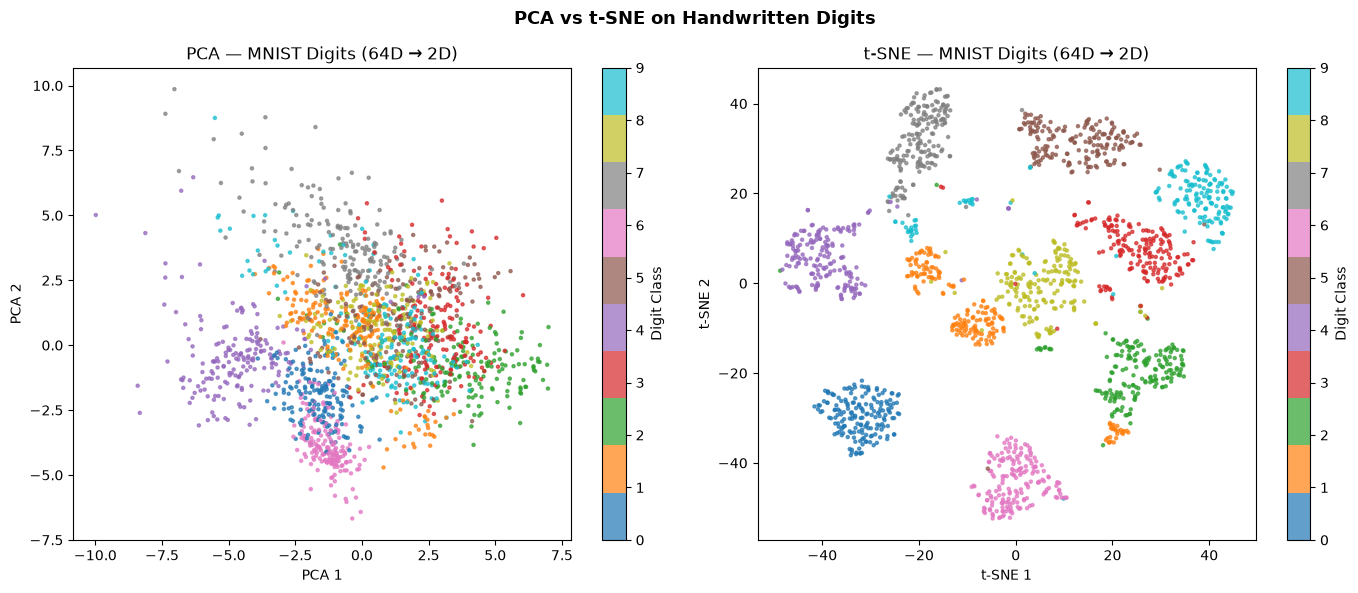

t-SNE reveals much cleaner clusters than PCA for complex data


In [5]:
# t-SNE on Digits dataset (64 features → 2D)
digits = load_digits()
X_dig = StandardScaler().fit_transform(digits.data)

# PCA first to speed up t-SNE (best practice)
X_pca50 = PCA(n_components=50).fit_transform(X_dig)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca50)

# Also run plain PCA for comparison
X_dig_pca2 = PCA(n_components=2).fit_transform(X_dig)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (X_2d, method) in zip(axes, [(X_dig_pca2, 'PCA'), (X_tsne, 't-SNE')]):
    sc = ax.scatter(X_2d[:,0], X_2d[:,1], c=digits.target, cmap='tab10', s=5, alpha=0.7)
    plt.colorbar(sc, ax=ax, label='Digit Class')
    ax.set_title(f"{method} — MNIST Digits (64D → 2D)")
    ax.set_xlabel(f"{method} 1"); ax.set_ylabel(f"{method} 2")

plt.suptitle("PCA vs t-SNE on Handwritten Digits", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/tsne_digits.png", dpi=100)
plt.show()
print("t-SNE reveals much cleaner clusters than PCA for complex data")

## 6. PCA as Feature Engineering for ML

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_w, y_w = load_wine().data, load_wine().target
X_tr, X_te, y_tr, y_te = train_test_split(X_w, y_w, test_size=0.25, random_state=42)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr); X_te_s = sc.transform(X_te)

results = {}
# Without PCA
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_tr_s, y_tr)
results['All 13 Features'] = {'dims':13, 'acc': lr.score(X_te_s, y_te)}

# With PCA (different n_components)
for n_comp in [2, 4, 7, 10]:
    pca = PCA(n_components=n_comp)
    X_tr_pca = pca.fit_transform(X_tr_s)
    X_te_pca = pca.transform(X_te_s)
    lr_pca = LogisticRegression(max_iter=1000, random_state=42)
    lr_pca.fit(X_tr_pca, y_tr)
    var = pca.explained_variance_ratio_.sum()
    results[f'PCA {n_comp} components ({var:.0%})'] = {
        'dims': n_comp, 'acc': lr_pca.score(X_te_pca, y_te)
    }

print(f"{'Setup':<35} {'Dimensions':>12} {'Test Accuracy':>15}")
print("-" * 62)
for name, info in results.items():
    print(f"{name:<35} {info['dims']:>12} {info['acc']:>15.2%}")

Setup                                 Dimensions   Test Accuracy
--------------------------------------------------------------
All 13 Features                               13          97.78%
PCA 2 components (55%)                         2          95.56%
PCA 4 components (74%)                         4          95.56%
PCA 7 components (89%)                         7         100.00%
PCA 10 components (96%)                       10          97.78%


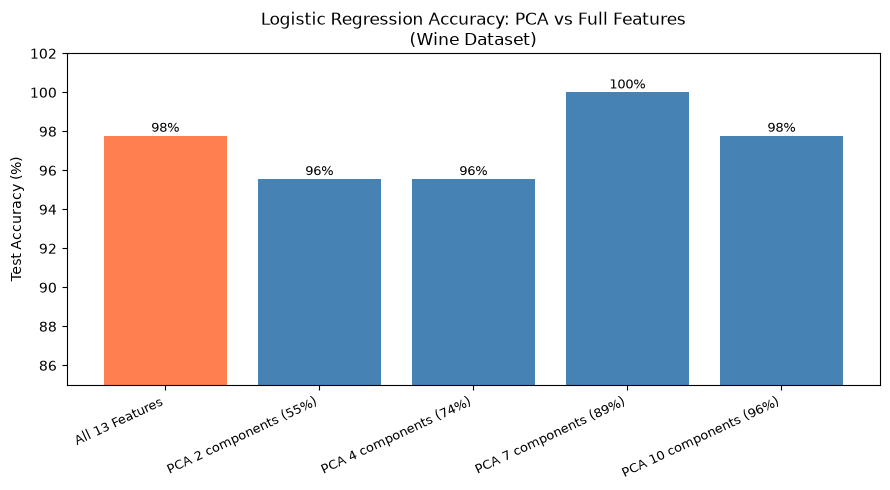

In [7]:
# Visualize the trade-off
labels = list(results.keys())
accs   = [v['acc'] for v in results.values()]
dims   = [v['dims'] for v in results.values()]

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['coral' if 'All' in l else 'steelblue' for l in labels]
bars = ax.bar(range(len(labels)), [a*100 for a in accs], color=colors)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=9)
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Logistic Regression Accuracy: PCA vs Full Features\n(Wine Dataset)")
ax.set_ylim(85, 102)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{acc:.0%}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("/tmp/pca_ml.png", dpi=100)
plt.show()

## 7. Image Compression with PCA

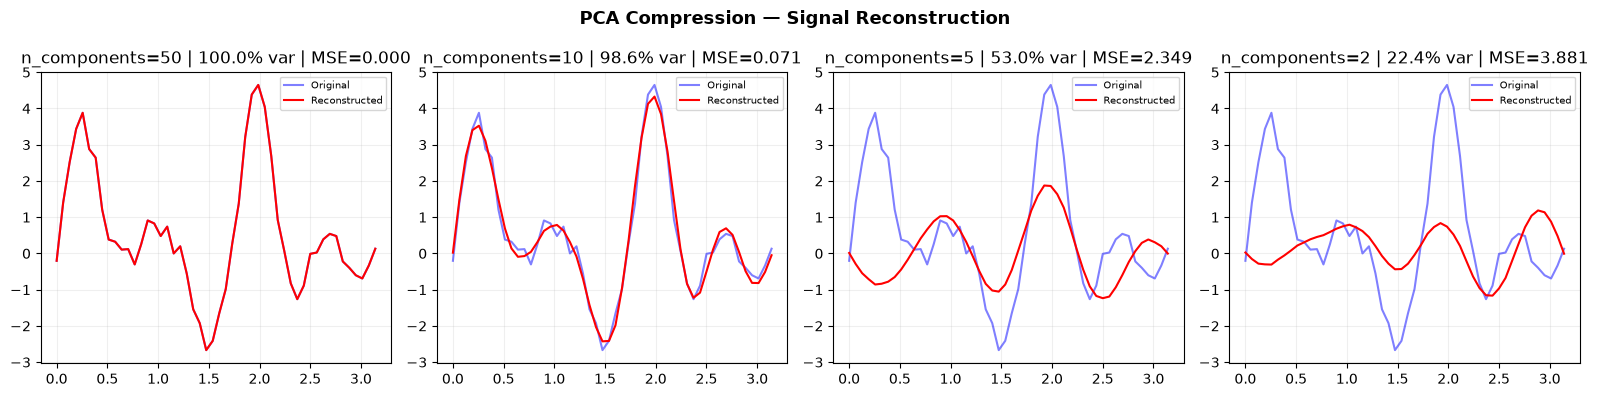

In [8]:
# Generate a synthetic "image" and compress it with PCA
np.random.seed(42)
n_samples = 1000

# Create structured synthetic image data (like face features)
t = np.linspace(0, np.pi, 50)
base_patterns = np.array([np.sin(k*t) for k in range(1, 11)])  # 10 patterns
random_coeffs = np.random.randn(n_samples, 10)
X_img = random_coeffs @ base_patterns + np.random.randn(n_samples, 50) * 0.3

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
compression_levels = [50, 10, 5, 2]

for ax, n_comp in zip(axes, compression_levels):
    pca = PCA(n_components=n_comp)
    X_compressed = pca.fit_transform(X_img)
    X_reconstructed = pca.inverse_transform(X_compressed)
    
    # Reconstruction error
    mse = np.mean((X_img - X_reconstructed)**2)
    var = pca.explained_variance_ratio_.sum()
    
    # Show one sample signal
    ax.plot(t, X_img[0], 'b-', alpha=0.5, linewidth=1.5, label='Original')
    ax.plot(t, X_reconstructed[0], 'r-', linewidth=1.5, label='Reconstructed')
    ax.set_title(f"n_components={n_comp} | {var:.1%} var | MSE={mse:.3f}")
    ax.legend(fontsize=7); ax.grid(alpha=0.2)

plt.suptitle("PCA Compression — Signal Reconstruction", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/pca_compression.png", dpi=100)
plt.show()

## Summary

| Method | Type | Best For |
|---|---|---|
| PCA | Linear | Feature reduction, preprocessing, visualization |
| t-SNE | Non-linear | Visualization ONLY (not for ML preprocessing) |
| UMAP | Non-linear | Both visualization & preprocessing (faster than t-SNE) |

**When to use PCA before ML:**
- When you have many correlated features
- When training is slow
- When you need to remove noise

**Next notebook →** `14_Model_Selection_Cross_Validation.ipynb`